In [1]:
import polars as pl
import pandas as pd



In [2]:
filepath = "tracking_results/DeepEcoHAB_20260501_211615_007DLC_DekrW18_the_future_of_EcohabNov22shuffle1_snapshot_best-260_el.h5"

In [28]:
tracking_df = pd.read_hdf(filepath)

long_pdf = (
    tracking_df
    .stack(["scorer", "individuals", "bodyparts"])
    #.rename(["x","y"])
    .reset_index()
)
tracking_lf = pl.from_pandas(long_pdf).lazy().rename({'level_0':"frame"}).drop('scorer') #ograć rename wczytywaniem z hdf

/tmp/ipykernel_747911/473144502.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(["scorer", "individuals", "bodyparts"])


In [ ]:
import numpy as np

tracking_lf = tracking_lf.with_columns(
    np.linalg.norm((pl.col('x').diff().over('individuals'), pl.col('y').diff().over('individuals'))).alias('jump'),
    pl.when(
        pl.col("likelihood") < 0.7
    ).then(
        None
    ).otherwise(
        pl.col('x')
    ).alias('x'),
    pl.when(
        pl.col("likelihood") < 0.7
    ).then(
        None
    ).otherwise(
        pl.col('y')
    ).alias('y'),
).filter(
    pl.col('bodyparts') == "Dorsal2",#to decide, maybe centroid instead
).drop(pl.col("likelihood"))#.collect()

In [30]:
tracking_lf.collect().to_pandas()

,frame,individuals,bodyparts,x,y,jump
0,0,ind1,Dorsal2,NaN,NaN,10.676478
1,0,ind2,Dorsal2,NaN,NaN,8.861125
2,0,ind3,Dorsal2,709.472900,479.450500,4.047424
3,0,ind4,Dorsal2,709.864502,360.614960,1.737175
4,0,ind5,Dorsal2,210.343430,308.119843,18.842027
...,...,...,...,...,...,...
763037,107999,ind4,Dorsal2,711.083008,360.641785,1.853736
763038,107999,ind5,Dorsal2,1108.964478,958.474060,12.555417
763039,107999,ind6,Dorsal2,NaN,NaN,8.890764
763040,107999,ind7,Dorsal2,415.452484,136.453751,19.012606


In [24]:
tracking_lf.with_columns(
    pl.col("x").interpolate().over("individuals").alias("x")
).collect().to_pandas()

,frame,individuals,bodyparts,x,y
0,0,ind1,Dorsal2,NaN,NaN
1,0,ind2,Dorsal2,NaN,NaN
2,0,ind3,Dorsal2,709.472900,479.450500
3,0,ind4,Dorsal2,709.864502,360.614960
4,0,ind5,Dorsal2,210.343430,308.119843
...,...,...,...,...,...
763037,107999,ind4,Dorsal2,711.083008,360.641785
763038,107999,ind5,Dorsal2,1108.964478,958.474060
763039,107999,ind6,Dorsal2,NaN,NaN
763040,107999,ind7,Dorsal2,415.452484,136.453751


In [6]:
antenna_df = pl.scan_csv(
    "tracking_results/DeepEcoHAB_20260501_211615_antenna_data.csv", 
    has_header=False,
    separator=";",
    new_columns=['antenna', 'tag', 'timestamp', 'datetime'],
    infer_schema_length=1000
    ).with_columns(
        pl.col('timestamp').str.to_integer(base=16)
    )

video_index = 7 #to extract from filename suffix
frames_per_video = 108000

antenna_df = antenna_df.with_columns(
    (pl.col('antenna')==10).cum_sum().alias('frame')
).filter(
    pl.col('frame').is_between(frames_per_video*video_index, frames_per_video*(video_index+1)-1)
).with_columns(
    (pl.col('frame')-pl.col('frame').first()).alias('frame')
)

In [7]:
antenna_df.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,10,01000000,13881021,2026-05-02T04:16:25.187506,0
1,10,01000000,13881025,2026-05-02T04:16:25.234955,1
2,10,01000000,13881028,2026-05-02T04:16:25.267095,2
3,10,01000000,13881031,2026-05-02T04:16:25.299101,3
4,10,01000000,13881035,2026-05-02T04:16:25.330489,4
...,...,...,...,...,...
115307,10,01000000,14241014,2026-05-02T05:16:25.269040,107995
115308,10,01000000,14241017,2026-05-02T05:16:25.300795,107996
115309,10,01000000,14241021,2026-05-02T05:16:25.341808,107997
115310,10,01000000,14241024,2026-05-02T05:16:25.371307,107998


In [8]:
antenna_df.filter(pl.col('tag')=='02000000').collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,1,02000000,14053249,2026-05-02T04:45:07.549451,51667


In [9]:
animal_detections = antenna_df.filter(
    pl.col("antenna") != 10#remove magic string
)

In [10]:
animal_detections.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721
1,5,F02AE61A,13883427,2026-05-02T04:16:49.269069,722
2,5,F02AE61A,13883431,2026-05-02T04:16:49.300830,723
3,5,F02AE61A,13883435,2026-05-02T04:16:49.348346,724
4,5,F02AE61A,13883439,2026-05-02T04:16:49.380227,725
...,...,...,...,...,...
7307,1,F02AE61A,14235857,2026-05-02T05:15:33.706488,106448
7308,1,F02AE61A,14235861,2026-05-02T05:15:33.737894,106449
7309,1,F02AE61A,14235865,2026-05-02T05:15:33.785172,106450
7310,1,F02AE61A,14235869,2026-05-02T05:15:33.826882,106451


In [11]:
animal_detections = animal_detections.with_columns(
    (
        pl.struct(["antenna", "tag"]).ne(pl.struct(["antenna", "tag"]).shift())
        | pl.col("frame").diff().gt(5)
    )
    .cum_sum()
    .cast(pl.Int16)
    .alias("run_id")
    .fill_null(0)
)
animal_detections.collect().to_pandas()
#group by run id of antenna and tag, with columns under antenna - in the future take the actual timestamp instead of frame

,antenna,tag,timestamp,datetime,frame,run_id
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0
1,5,F02AE61A,13883427,2026-05-02T04:16:49.269069,722,0
2,5,F02AE61A,13883431,2026-05-02T04:16:49.300830,723,0
3,5,F02AE61A,13883435,2026-05-02T04:16:49.348346,724,0
4,5,F02AE61A,13883439,2026-05-02T04:16:49.380227,725,0
...,...,...,...,...,...,...
7307,1,F02AE61A,14235857,2026-05-02T05:15:33.706488,106448,1459
7308,1,F02AE61A,14235861,2026-05-02T05:15:33.737894,106449,1459
7309,1,F02AE61A,14235865,2026-05-02T05:15:33.785172,106450,1459
7310,1,F02AE61A,14235869,2026-05-02T05:15:33.826882,106451,1459


In [12]:
antenna_with_coords = animal_detections.join(
    tracking_lf,
    on = 'frame',
    how = 'left'
)

In [13]:
antenna_with_coords = antenna_with_coords.filter((pl.col('tag') != '02000000') & (pl.col('tag') != '02000060')) #maybe use sanitation for that

In [14]:
antenna_with_coords.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame,run_id,individuals,bodyparts,x,y
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind1,Dorsal2,1044.807983,744.289185
1,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind2,Dorsal2,NaN,NaN
2,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind3,Dorsal2,708.658997,480.565552
3,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind4,Dorsal2,711.786011,360.191193
4,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind5,Dorsal2,201.814240,310.670593
...,...,...,...,...,...,...,...,...,...,...
51522,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind4,Dorsal2,711.827576,360.731415
51523,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind5,Dorsal2,1131.467163,946.468811
51524,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind6,Dorsal2,389.522766,170.759018
51525,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind7,Dorsal2,170.023682,366.717133


In [15]:
antenna_with_coords.group_by(
    ['run_id', 'antenna', 'tag', 'individuals']
).agg(
    pl.col("x").mean(),
    pl.col("y").mean(),
).collect().to_pandas()

,run_id,antenna,tag,individuals,x,y
0,1147,6,6D68A819,ind6,778.425720,232.386154
1,1152,7,F02AE61A,ind1,851.521484,245.255447
2,1233,4,EE1CEC1A,ind1,192.187500,293.402725
3,992,5,12F5FF19,ind5,NaN,NaN
4,1073,0,3AFE9F1A,ind3,463.922058,247.544571
...,...,...,...,...,...,...
10502,1427,6,D5969C1A,ind3,933.646884,1141.981662
10503,1412,4,3AFE9F1A,ind6,710.815292,360.035603
10504,210,0,D5969C1A,ind5,289.049398,220.907664
10505,93,7,3AFE9F1A,ind2,137.445450,394.166144


In [16]:
tst = antenna_with_coords.group_by(
    ['antenna']
).agg(
    pl.col("x").mean(),
    pl.col("y").mean(),
).collect()

In [17]:
import numpy as np
img = np.zeros([1280, 1280])

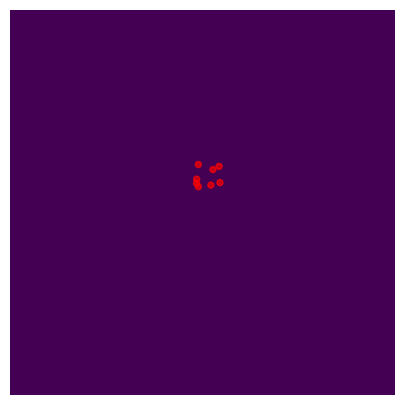

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img)
ax.axis('off')

for x in tst.to_numpy():
    circle = Circle((x[1], x[2]), 10, color='red', fill=True, alpha=0.7)
    ax.add_patch(circle)

plt.show()

In [19]:
antenna_with_coords.filter(
    pl.col('antenna') == 7
).with_columns(
    pl.col('x').floordiv(10)
).collect().to_pandas()

,antenna,tag,timestamp,datetime,frame,run_id,individuals,bodyparts,x,y
0,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind1,Dorsal2,30.0,1126.216064
1,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind2,Dorsal2,93.0,1123.691895
2,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind3,Dorsal2,70.0,480.403137
3,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind4,Dorsal2,NaN,NaN
4,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind5,Dorsal2,27.0,316.185333
...,...,...,...,...,...,...,...,...,...,...
5282,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind4,Dorsal2,71.0,360.862305
5283,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind5,Dorsal2,112.0,955.274536
5284,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind6,Dorsal2,46.0,245.456696
5285,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind7,Dorsal2,40.0,1096.478394


In [20]:
import polars as pl
data = [[510,250], [810,250], [1045,780], [1045,780], [810,1010], [510,1010], [270, 780], [270,480]]
antenna_locations = pl.DataFrame({"x":[510,810, 1045,1045,810,510,270,270], "y":[250,250,480,780,1010,1010,780,480]})
antenna_locations

x,y
i64,i64
510,250
810,250
1045,480
1045,780
810,1010
510,1010
270,780
270,480


In [21]:
antenna_with_coords_t = antenna_with_coords.select(['antenna', 'frame', 'tag', 'individuals', 'run_id', 'x', 'y'])

In [22]:
for i, d in enumerate(data):
    antenna_with_coords_t = antenna_with_coords_t.with_columns(
        (np.linalg.norm(np.array([pl.col("x"), pl.col("y")])- np.array([d[0], d[1]]))).alias(f"dist{i}")
    )

In [23]:
antenna_with_coords_t.filter(
    pl.col("dist1") < 150
).collect().to_pandas()

,antenna,frame,tag,individuals,run_id,x,y,dist0,dist1,dist2,dist3,dist4,dist5,dist6,dist7
0,5,721,F02AE61A,ind4,0,711.786011,360.191193,229.912360,147.607881,535.976676,535.976676,657.189070,680.418313,609.437703,457.743410
1,5,722,F02AE61A,ind4,0,711.625122,360.281342,229.814412,147.782241,536.006121,536.006121,657.124000,680.284518,609.258977,457.564537
2,5,723,F02AE61A,ind4,0,711.447693,360.558868,229.792159,148.107463,535.899248,535.899248,656.876199,679.966879,608.939183,457.320729
3,5,724,F02AE61A,ind4,0,711.449280,360.572205,229.799967,148.116363,535.887823,535.887823,656.862776,679.954612,608.931147,457.318778
4,5,725,F02AE61A,ind4,0,710.935364,361.071075,229.590514,148.830729,535.817716,535.817716,656.446914,679.325967,608.214961,456.692549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6787,1,106448,F02AE61A,ind4,1459,711.051697,361.046906,229.680648,148.735275,535.764094,535.764094,656.453262,679.383473,608.315950,456.811162
6788,1,106449,F02AE61A,ind4,1459,711.068176,361.037598,229.690574,148.717362,535.761101,535.761101,656.459980,679.397241,608.334308,456.829497
6789,1,106450,F02AE61A,ind4,1459,711.702881,360.067596,229.780173,147.570998,536.125166,536.125166,657.323705,680.511706,609.462598,457.695550
6790,1,106451,F02AE61A,ind4,1459,711.678223,360.581055,230.004946,147.970746,535.738424,535.738424,656.819715,680.014023,609.091047,457.537470
